# Parameter Golf - Google Colab (step1)

Train a GPT language model optimized for bits-per-byte (BPB) on FineWeb validation.

**Before running:** Go to `Runtime > Change runtime type` and select **A100** or **H100 GPU**.

The notebook auto-detects your GPU (T4/L4/A100/H100) and configures batch sizes to maximize utilization.

## 1. Install Dependencies

In [1]:
!pip install -q torch numpy tqdm huggingface-hub sentencepiece

## 2. Clone Repo & Download Data

In [2]:
import os

REPO_DIR = "/content/parameter-golf"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/openai/parameter-golf.git {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/parameter-golf'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 426 (delta 0), reused 0 (delta 0), pack-reused 424 (from 2)
Receiving objects: 100% (426/426), 778.63 KiB | 31.14 MiB/s, done.
Resolving deltas: 100% (192/192), done.
Working directory: /content/parameter-golf


In [3]:
# Download training shards + validation + tokenizer
# A100 Pro: 40 shards (~8GB) is a good default. Max 80 (~16GB).
TRAIN_SHARDS = 40

!python data/cached_challenge_fineweb.py --train-shards {TRAIN_SHARDS}

manifest.json: 1.93kB [00:00, 5.44MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 124M/124M [00:02<00:00, 61.2MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 165MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 141MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s] 
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 

## 3. Detect GPU & Configure Hyperparameters

In [4]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Go to Runtime > Change runtime type > GPU")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
compute_cap = torch.cuda.get_device_capability(0)
supports_flash = compute_cap[0] >= 8  # Ampere+ (sm80)

print(f"GPU: {gpu_name}")
print(f"Memory: {gpu_mem_gb:.1f} GB")
print(f"Compute capability: {compute_cap[0]}.{compute_cap[1]}")
print(f"Flash attention: {'yes' if supports_flash else 'no (will use mem_efficient)'}")
print()

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB
Compute capability: 8.0
Flash attention: yes



In [5]:
# ============================================================
# EXPERIMENT CONFIG - Edit these to run different experiments!
# ============================================================

# Auto-select profile based on GPU memory
if gpu_mem_gb >= 70:    # H100 80GB
    PROFILE = "h100"
elif gpu_mem_gb >= 35:  # A100 40GB / A100 80GB
    PROFILE = "a100"
elif gpu_mem_gb >= 20:  # L4 24GB
    PROFILE = "l4"
else:                   # T4 16GB
    PROFILE = "t4"

# NOTE: Single-GPU training uses grad_accum_steps=8 (hardcoded as 8//world_size).
# Each step does 8 sequential forward/backward passes of (batch_tokens/8) tokens.
# Larger batches = better gradient quality but slower steps.
# Target: ~200-300ms/step for fast experiments (~20-25 min for 5000 steps).

PROFILES = {
    "t4": {
        "TRAIN_BATCH_TOKENS": "65536",     # microbatch: 8K tokens → ~200ms/step
        "VAL_BATCH_SIZE":     "65536",
        "TRAIN_SEQ_LEN":      "512",
        "NUM_LAYERS":         "6",
        "MODEL_DIM":          "384",
        "NUM_HEADS":          "6",
        "NUM_KV_HEADS":       "3",
    },
    "l4": {
        "TRAIN_BATCH_TOKENS": "131072",    # microbatch: 16K tokens → ~250ms/step
        "VAL_BATCH_SIZE":     "131072",
        "TRAIN_SEQ_LEN":      "1024",
        "NUM_LAYERS":         "9",
        "MODEL_DIM":          "512",
        "NUM_HEADS":          "8",
        "NUM_KV_HEADS":       "4",
    },
    "a100": {
        # A100 40GB single-GPU: 256K batch → 32K microbatch × 8 accum → ~300ms/step
        # 5000 steps ≈ 25 min. Good balance of speed + gradient quality.
        "TRAIN_BATCH_TOKENS": "262144",
        "VAL_BATCH_SIZE":     "262144",
        "TRAIN_SEQ_LEN":      "1024",
        "NUM_LAYERS":         "9",
        "MODEL_DIM":          "512",
        "NUM_HEADS":          "8",
        "NUM_KV_HEADS":       "4",
    },
    "h100": {
        # H100 80GB: faster GPU, can afford larger batch at same step time.
        "TRAIN_BATCH_TOKENS": "524288",    # microbatch: 64K tokens → ~300ms/step
        "VAL_BATCH_SIZE":     "524288",
        "TRAIN_SEQ_LEN":      "1024",
        "NUM_LAYERS":         "9",
        "MODEL_DIM":          "512",
        "NUM_HEADS":          "8",
        "NUM_KV_HEADS":       "4",
    },
}

# Common settings (override any profile value below)
config = {
    **PROFILES[PROFILE],
    "ITERATIONS":           "5000",
    "WARMDOWN_ITERS":       "600",
    "MAX_WALLCLOCK_SECONDS": "1800",   # 30 min cap
    "VAL_LOSS_EVERY":       "500",
    "TRAIN_LOG_EVERY":      "100",
}

# ----------------------------------------------------------
# Override any hyperparameter here for your experiment:
# config["NUM_LAYERS"] = "12"
# config["MODEL_DIM"] = "256"
# config["MATRIX_LR"] = "0.02"
# config["MLP_MULT"] = "3"
# ----------------------------------------------------------

# Apply to environment
for k, v in config.items():
    os.environ[k] = v

print(f"Profile: {PROFILE} ({gpu_name})")
print(f"Config:")
for k, v in sorted(config.items()):
    print(f"  {k}={v}")

Profile: a100 (NVIDIA A100-SXM4-40GB)
Config:
  ITERATIONS=5000
  MAX_WALLCLOCK_SECONDS=1800
  MODEL_DIM=512
  NUM_HEADS=8
  NUM_KV_HEADS=4
  NUM_LAYERS=9
  TRAIN_BATCH_TOKENS=262144
  TRAIN_LOG_EVERY=100
  TRAIN_SEQ_LEN=1024
  VAL_BATCH_SIZE=262144
  VAL_LOSS_EVERY=500
  WARMDOWN_ITERS=600


## 4. Patch SDP Backends for GPU Compatibility

In [6]:
# T4 and older GPUs don't support flash attention.
# Patch train_gpt.py to use mem_efficient_sdp as fallback.

if not supports_flash:
    with open("train_gpt.py", "r") as f:
        code = f.read()

    # Replace: enable only flash_sdp → enable mem_efficient + math as fallbacks
    old = """    enable_cudnn_sdp(False)
    enable_flash_sdp(True)
    enable_mem_efficient_sdp(False)
    enable_math_sdp(False)"""

    new = """    enable_cudnn_sdp(False)
    enable_flash_sdp(False)
    enable_mem_efficient_sdp(True)
    enable_math_sdp(True)"""

    if old in code:
        code = code.replace(old, new)
        with open("train_gpt.py", "w") as f:
            f.write(code)
        print("Patched: flash_sdp -> mem_efficient_sdp + math_sdp")
    else:
        print("Warning: SDP block not found (already patched or script changed)")
else:
    print(f"Flash attention supported on {gpu_name} - no patch needed")

Flash attention supported on NVIDIA A100-SXM4-40GB - no patch needed


## 5. Train!

In [7]:
# Build the env string from config for the subprocess
env_str = " ".join(f"{k}={v}" for k, v in config.items())
!{env_str} python train_gpt.py

logs/66b9fe45-d9d3-4a62-9983-8cf6e1bc3d26.txt
val_bpb:enabled tokenizer_kind=sentencepiece tokenizer_path=./data/tokenizers/fineweb_1024_bpe.model
train_loader:dataset:fineweb10B_sp1024 train_shards:40
val_loader:shards pattern=./data/datasets/fineweb10B_sp1024/fineweb_val_*.bin tokens:62021632
model_params:17059912
world_size:1 grad_accum_steps:8
sdp_backends:cudnn=False flash=True mem_efficient=False math=False
attention_mode:gqa num_heads:8 num_kv_heads:4
tie_embeddings:True embed_lr:0.05 head_lr:0.0 matrix_lr:0.04 scalar_lr:0.04
train_batch_tokens:262144 train_seq_len:1024 iterations:5000 warmup_steps:20 max_wallclock_seconds:1800.000
seed:1337
warmup_step:1/20
warmup_step:2/20
warmup_step:3/20
warmup_step:4/20
warmup_step:5/20
warmup_step:6/20
warmup_step:7/20
warmup_step:8/20
warmup_step:9/20
warmup_step:10/20
warmup_step:11/20
warmup_step:12/20
warmup_step:13/20
warmup_step:14/20
warmup_step:15/20
warmup_step:16/20
warmup_step:17/20
warmup_step:18/20
warmup_step:19/20
warmup_ste

## 6. Results

Reading: logs/66b9fe45-d9d3-4a62-9983-8cf6e1bc3d26.txt

Final val_loss: 2.1639
Final val_bpb:  1.2816
Artifact size:  15,839,316 bytes (15.84 MB / 16.00 MB limit)


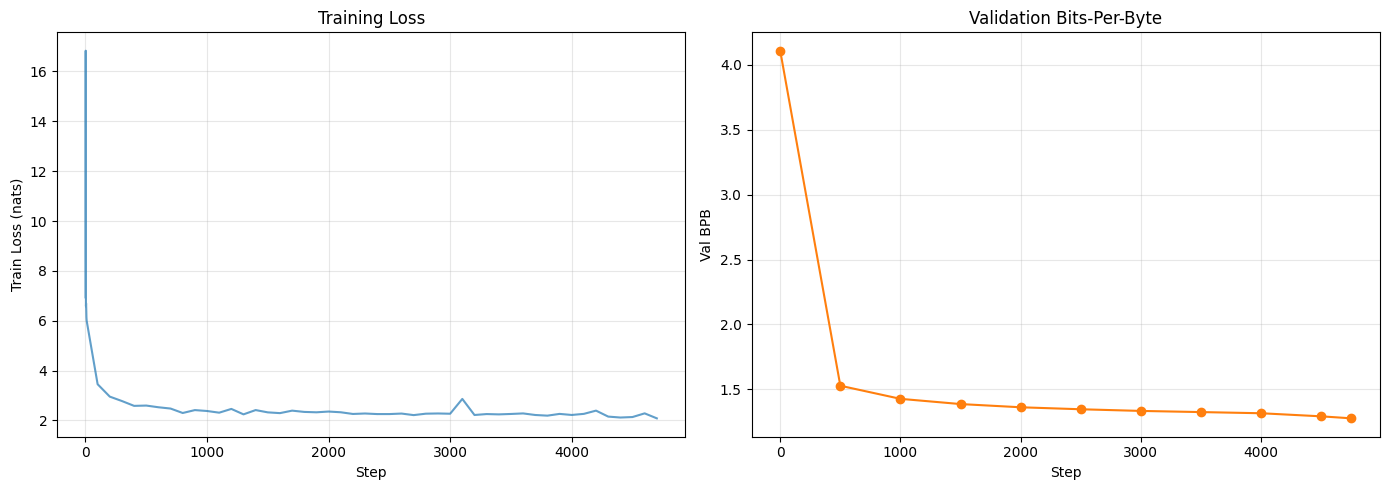

In [8]:
import re
import glob as globmod
import matplotlib.pyplot as plt

# Find the most recent log file
log_files = sorted(globmod.glob("logs/*.txt"), key=os.path.getmtime)
if not log_files:
    print("No log files found. Did training complete?")
else:
    log_path = log_files[-1]
    print(f"Reading: {log_path}\n")

    with open(log_path) as f:
        log_text = f.read()

    # Parse training loss
    train_steps, train_losses = [], []
    for m in re.finditer(r"step:(\d+).*?train_loss:([\d.]+)", log_text):
        train_steps.append(int(m.group(1)))
        train_losses.append(float(m.group(2)))

    # Parse validation BPB
    val_steps, val_bpbs = [], []
    for m in re.finditer(r"step:(\d+).*?val_bpb:([\d.]+)", log_text):
        val_steps.append(int(m.group(1)))
        val_bpbs.append(float(m.group(2)))

    # Parse final results
    final_match = re.search(r"final_int8_zlib_roundtrip val_loss:([\d.]+) val_bpb:([\d.]+)", log_text)
    size_match = re.search(r"Total submission size int8\+zlib: (\d+) bytes", log_text)

    if final_match:
        print(f"Final val_loss: {final_match.group(1)}")
        print(f"Final val_bpb:  {final_match.group(2)}")
    if size_match:
        size_bytes = int(size_match.group(1))
        print(f"Artifact size:  {size_bytes:,} bytes ({size_bytes/1e6:.2f} MB / 16.00 MB limit)")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if train_steps:
        axes[0].plot(train_steps, train_losses, alpha=0.7)
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Train Loss (nats)")
        axes[0].set_title("Training Loss")
        axes[0].grid(True, alpha=0.3)

    if val_steps:
        axes[1].plot(val_steps, val_bpbs, "o-", color="tab:orange")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Val BPB")
        axes[1].set_title("Validation Bits-Per-Byte")
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. Hyperparameter Reference

Override any of these in the config cell (Cell 3) before training:

| Variable | Default | Description |
|----------|---------|-------------|
| `VOCAB_SIZE` | 1024 | SentencePiece BPE vocab size |
| `NUM_LAYERS` | 9 | Transformer blocks |
| `MODEL_DIM` | 512 | Hidden dimension |
| `NUM_HEADS` | 8 | Attention heads |
| `NUM_KV_HEADS` | 4 | KV heads (GQA) |
| `MLP_MULT` | 2 | MLP expansion factor |
| `TRAIN_SEQ_LEN` | 1024 | Context length |
| `TRAIN_BATCH_TOKENS` | 524288 | Tokens per training step |
| `ITERATIONS` | 20000 | Max training steps |
| `MAX_WALLCLOCK_SECONDS` | 600 | Wall-clock time limit |
| `MATRIX_LR` | 0.04 | Muon LR for 2D params |
| `SCALAR_LR` | 0.04 | Adam LR for 1D params |
| `EMBED_LR` | 0.6 | Embedding LR |
| `TIE_EMBEDDINGS` | 1 | Tie input/output embeddings |

## 8. Experiment Suite

A structured set of experiments informed by the [leaderboard](https://github.com/openai/parameter-golf/tree/main/records/track_10min_16mb) and research analysis. Results on single A100 are **directional** — relative comparisons are valid even if absolute BPB differs from 8xH100.

### Tier 1: Config-Only (env vars, no code changes)

| # | Name | Key Changes | Rationale |
|---|------|------------|-----------|
| 1 | `baseline` | Default 9L/512d/MLP2x | Reference point |
| 2 | `mlp_3x` | MLP_MULT=3 | Biggest single win on leaderboard |
| 3 | `mlp_4x` | MLP_MULT=4 | Test diminishing returns |
| 4 | `depth_10L` | 10 layers | Leaderboard sweet spot |
| 5 | `depth_12L` | 12 layers, dim=384 | More depth, less width |
| 6 | `wide_640` | dim=640, 10 heads | Research: wider > deeper at small scale |
| 7 | `seq_2048` | seq_len=2048 | Top submission uses this |
| 8 | `big_batch` | 524K tokens/step | Match 8xH100 default batch |
| 9 | `aggressive_gqa` | 2 KV heads | Save KV params for more capacity |
| 10 | `low_lr` | matrix_lr=0.02 | Leaderboard optimal |
| 11 | `long_warmdown` | warmdown=3000 | All top submissions use this |
| 12 | `high_momentum` | momentum=0.99 | Top submissions ramp to 0.99 |
| 13 | `combined_best` | 10L + MLP3x + low LR + seq2048 | Best known config combo |

### Tier 2: Code Patches (modify train_gpt.py before training)

| # | Name | Modification | Source |
|---|------|-------------|--------|
| 14 | `ortho_init` | Orthogonal weight init | All top submissions |
| 15 | `smeargate` | Learned bigram gate at embedding | Top 3 submissions |
| 16 | `bigram_hash` | Hash-based bigram embeddings | Top 2 submissions |
| 17 | `depth_recurrent` | 3 shared blocks x 3 loops | Huginn, PRs #5/#8/#11 |
| 18 | `bitlinear_ternary` | Ternary QAT {-1,0,+1} weights | BitNet b1.58 (untried on leaderboard!) |

Run Tier 2 experiments by setting `EXPERIMENT` AND running the patch cell before training.

In [9]:
# ============================================================
# SELECT YOUR EXPERIMENT HERE
# ============================================================
EXPERIMENT = "depth_10L"  # <-- Change this to run different experiments

# Tier 1: Config-only experiments (no code patches needed)
EXPERIMENTS = {
    # --- Architecture ---
    "baseline": {},  # Default: 9L, 512d, MLP 2x
    "mlp_3x": {
        "MLP_MULT": "3",
    },
    "mlp_4x": {
        "MLP_MULT": "4",
    },
    "depth_10L": {
        "NUM_LAYERS": "10",
    },
    "depth_12L": {
        "NUM_LAYERS": "12",
        "MODEL_DIM": "384",
        "NUM_HEADS": "6",
        "NUM_KV_HEADS": "3",
    },
    "wide_640": {
        "MODEL_DIM": "640",
        "NUM_HEADS": "10",
        "NUM_KV_HEADS": "5",
    },
    "seq_2048": {
        "TRAIN_SEQ_LEN": "2048",
    },
    "big_batch": {
        # Match 8xH100 competition default (slower steps, better gradients)
        "TRAIN_BATCH_TOKENS": "524288",
        "VAL_BATCH_SIZE": "524288",
    },
    "aggressive_gqa": {
        "NUM_KV_HEADS": "2",
    },

    # --- Training recipe ---
    "low_lr": {
        "MATRIX_LR": "0.02",
        "SCALAR_LR": "0.02",
    },
    "long_warmdown": {
        "WARMDOWN_ITERS": "3000",
    },
    "high_momentum": {
        "MUON_MOMENTUM": "0.99",
        "MUON_MOMENTUM_WARMUP_START": "0.92",
        "MUON_MOMENTUM_WARMUP_STEPS": "1500",
    },

    # --- Combined best known config ---
    "combined_best": {
        "NUM_LAYERS": "10",
        "MLP_MULT": "3",
        "MATRIX_LR": "0.02",
        "SCALAR_LR": "0.02",
        "TIED_EMBED_LR": "0.03",
        "TRAIN_SEQ_LEN": "2048",
        "WARMDOWN_ITERS": "3000",
        "MUON_MOMENTUM": "0.99",
        "MUON_MOMENTUM_WARMUP_START": "0.92",
        "MUON_MOMENTUM_WARMUP_STEPS": "1500",
        "GRAD_CLIP_NORM": "0.3",
    },

    # Tier 2 experiments (need code patches from next cell first)
    "ortho_init": {},
    "smeargate": {},
    "bigram_hash": {},
    "depth_recurrent": {
        "NUM_LAYERS": "9",  # 3 shared x 3 loops = 9 effective
    },
    "bitlinear_ternary": {
        "NUM_LAYERS": "12",
        "MODEL_DIM": "640",
        "NUM_HEADS": "10",
        "NUM_KV_HEADS": "5",
        "EMBED_LR": "1.0",
        "MATRIX_LR": "0.08",
        "SCALAR_LR": "0.08",
    },
}

TIER2_EXPERIMENTS = {"ortho_init", "smeargate", "bigram_hash", "depth_recurrent", "bitlinear_ternary"}

if EXPERIMENT not in EXPERIMENTS:
    print(f"Unknown experiment: {EXPERIMENT}")
    print(f"Available: {', '.join(sorted(EXPERIMENTS.keys()))}")
else:
    exp_config = EXPERIMENTS[EXPERIMENT]
    config.update(exp_config)
    for k, v in config.items():
        os.environ[k] = v
    print(f"Experiment: {EXPERIMENT}")
    if EXPERIMENT in TIER2_EXPERIMENTS:
        print("WARNING: This is a Tier 2 experiment. Run the patch cell below BEFORE training!")
    print(f"Config overrides: {exp_config if exp_config else '(none - using defaults)'}")
    print(f"\nFull config:")
    for k, v in sorted(config.items()):
        print(f"  {k}={v}")

Experiment: depth_10L
Config overrides: {'NUM_LAYERS': '10'}

Full config:
  ITERATIONS=5000
  MAX_WALLCLOCK_SECONDS=1800
  MODEL_DIM=512
  NUM_HEADS=8
  NUM_KV_HEADS=4
  NUM_LAYERS=10
  TRAIN_BATCH_TOKENS=262144
  TRAIN_LOG_EVERY=100
  TRAIN_SEQ_LEN=1024
  VAL_BATCH_SIZE=262144
  VAL_LOSS_EVERY=500
  WARMDOWN_ITERS=600


### Tier 2: Code Patches

Run this cell to apply code modifications for Tier 2 experiments. Only patches the experiment you selected above. **To reset patches**, re-run the clone cell (Section 2) or `!git checkout train_gpt.py`.

In [10]:
import subprocess

def reset_script():
    """Reset train_gpt.py to upstream version."""
    subprocess.run(["git", "checkout", "train_gpt.py"], check=True)
    print("Reset train_gpt.py to upstream")

def read_script():
    with open("train_gpt.py", "r") as f:
        return f.read()

def write_script(code):
    with open("train_gpt.py", "w") as f:
        f.write(code)

def patch_replace(code, old, new, label=""):
    if old not in code:
        print(f"WARNING: patch target not found{' (' + label + ')' if label else ''}")
        return code
    code = code.replace(old, new, 1)
    print(f"Applied patch: {label}")
    return code

# -------------------------------------------------------------------
# PATCH: ortho_init — Orthogonal weight initialization
# All top leaderboard submissions use this. Replaces default init.
# -------------------------------------------------------------------
def patch_ortho_init(code):
    old = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        for module in self.modules():
            if isinstance(module, nn.Linear) and getattr(module, "_zero_init", False):
                nn.init.zeros_(module.weight)'''

    new = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        num_layers = len(self.blocks)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if getattr(module, "_zero_init", False):
                    nn.init.zeros_(module.weight)
                elif module.weight.ndim == 2 and min(module.weight.shape) > 1:
                    nn.init.orthogonal_(module.weight, gain=1.0)
                    if hasattr(module, "_zero_init") and not module._zero_init:
                        module.weight.data *= 1.0 / (2 * num_layers) ** 0.5'''

    return patch_replace(code, old, new, "ortho_init")


# -------------------------------------------------------------------
# PATCH: smeargate — Learned per-dimension gate blending current
# token with previous token at embedding layer. ~512 params.
# Used by top 3 leaderboard submissions.
# -------------------------------------------------------------------
def patch_smeargate(code):
    # Add SmearGate class after MLP class
    old = '''class Block(nn.Module):'''
    new = '''class SmearGate(nn.Module):
    """Learned per-dimension gate blending current token embedding with previous token."""
    def __init__(self, dim: int, init_keep: float = 0.95):
        super().__init__()
        # gate > 0 keeps current token, gate < 0 blends previous
        init_val = math.log(init_keep / (1 - init_keep))  # inverse sigmoid
        self.gate = nn.Parameter(torch.full((dim,), init_val, dtype=torch.float32))

    def forward(self, x: Tensor) -> Tensor:
        g = torch.sigmoid(self.gate.to(dtype=x.dtype))[None, None, :]
        x_prev = torch.cat([x[:, :1, :], x[:, :-1, :]], dim=1)
        return g * x + (1 - g) * x_prev


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "smeargate class")

    # Add SmearGate usage in GPT.__init__
    old2 = "        self.final_norm = RMSNorm()"
    new2 = "        self.smear_gate = SmearGate(model_dim)\n        self.final_norm = RMSNorm()"
    code = patch_replace(code, old2, new2, "smeargate init")

    # Apply SmearGate in forward
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids)
        x = self.smear_gate(x)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    code = patch_replace(code, old3, new3, "smeargate forward")
    return code


# -------------------------------------------------------------------
# PATCH: bigram_hash — Hash-based bigram embedding table.
# Maps adjacent token pairs via hash into learned embedding table.
# Used by top 2 leaderboard submissions.
# -------------------------------------------------------------------
def patch_bigram_hash(code):
    # Add BigramHash class
    old = '''class Block(nn.Module):'''
    new = '''class BigramHash(nn.Module):
    """Hash consecutive token pairs into a learned embedding table."""
    def __init__(self, vocab_size: int, dim: int, num_buckets: int = 4096, hash_dim: int = 128):
        super().__init__()
        self.num_buckets = num_buckets
        self.hash_table = nn.Embedding(num_buckets, hash_dim)
        self.proj = CastedLinear(hash_dim, dim, bias=False)
        nn.init.normal_(self.hash_table.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)

    def forward(self, input_ids: Tensor) -> Tensor:
        # Shift input_ids to get previous tokens (use 0 for first position)
        prev_ids = torch.cat([torch.zeros_like(input_ids[:, :1]), input_ids[:, :-1]], dim=1)
        hash_ids = (prev_ids * 31 + input_ids) % self.num_buckets
        return self.proj(self.hash_table(hash_ids))


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "bigram_hash class")

    # Add BigramHash in GPT.__init__
    old2 = "        self.final_norm = RMSNorm()"
    new2 = "        self.bigram_hash = BigramHash(vocab_size, model_dim)\n        self.final_norm = RMSNorm()"
    code = patch_replace(code, old2, new2, "bigram_hash init")

    # Apply BigramHash in forward
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids) + self.bigram_hash(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    code = patch_replace(code, old3, new3, "bigram_hash forward")
    return code


# -------------------------------------------------------------------
# PATCH: depth_recurrent — 3 shared blocks looped 3 times each
# = 9 effective layers from 3 physical layers. Based on Huginn.
# -------------------------------------------------------------------
def patch_depth_recurrent(code):
    # Replace the GPT block creation to use shared blocks
    old = '''        self.blocks = nn.ModuleList(
            [
                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                )
                for i in range(num_layers)
            ]
        )'''
    # Create 3 physical blocks, each looped 3 times
    new = '''        self._num_physical_blocks = 3
        self._loops_per_block = num_layers // self._num_physical_blocks
        if self._loops_per_block < 1:
            self._loops_per_block = 1
        # Physical blocks (shared weights)
        self.blocks = nn.ModuleList(
            [
                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                )
                for i in range(self._num_physical_blocks)
            ]
        )
        # Per-loop scale factors for differentiation
        effective_depth = self._num_physical_blocks * self._loops_per_block
        self.loop_scales = nn.Parameter(torch.ones(effective_depth, model_dim, dtype=torch.float32))'''
    code = patch_replace(code, old, new, "depth_recurrent blocks")

    # Update encoder/decoder layer counts
    old2 = '''        self.num_encoder_layers = num_layers // 2
        self.num_decoder_layers = num_layers - self.num_encoder_layers
        self.num_skip_weights = min(self.num_encoder_layers, self.num_decoder_layers)
        self.skip_weights = nn.Parameter(torch.ones(self.num_skip_weights, model_dim, dtype=torch.float32))'''
    new2 = '''        effective_layers = self._num_physical_blocks * self._loops_per_block if hasattr(self, '_num_physical_blocks') else num_layers
        self.num_encoder_layers = effective_layers // 2
        self.num_decoder_layers = effective_layers - self.num_encoder_layers
        self.num_skip_weights = min(self.num_encoder_layers, self.num_decoder_layers)
        self.skip_weights = nn.Parameter(torch.ones(self.num_skip_weights, model_dim, dtype=torch.float32))'''
    code = patch_replace(code, old2, new2, "depth_recurrent encoder/decoder")

    # Replace forward loop to use shared blocks with looping
    old3 = '''        # First half stores skips; second half reuses them in reverse order.
        for i in range(self.num_encoder_layers):
            x = self.blocks[i](x, x0)
            skips.append(x)
        for i in range(self.num_decoder_layers):
            if skips:
                x = x + self.skip_weights[i].to(dtype=x.dtype)[None, None, :] * skips.pop()
            x = self.blocks[self.num_encoder_layers + i](x, x0)'''
    new3 = '''        # Depth-recurrent: loop through physical blocks multiple times
        layer_idx = 0
        if hasattr(self, '_num_physical_blocks'):
            for block_i in range(self._num_physical_blocks):
                for loop_j in range(self._loops_per_block):
                    scale = self.loop_scales[layer_idx].to(dtype=x.dtype)[None, None, :]
                    if layer_idx < self.num_encoder_layers:
                        x = self.blocks[block_i](x, x0) * scale
                        skips.append(x)
                    else:
                        dec_i = layer_idx - self.num_encoder_layers
                        if skips:
                            x = x + self.skip_weights[dec_i].to(dtype=x.dtype)[None, None, :] * skips.pop()
                        x = self.blocks[block_i](x, x0) * scale
                    layer_idx += 1
        else:
            for i in range(self.num_encoder_layers):
                x = self.blocks[i](x, x0)
                skips.append(x)
            for i in range(self.num_decoder_layers):
                if skips:
                    x = x + self.skip_weights[i].to(dtype=x.dtype)[None, None, :] * skips.pop()
                x = self.blocks[self.num_encoder_layers + i](x, x0)'''
    code = patch_replace(code, old3, new3, "depth_recurrent forward")
    return code


# -------------------------------------------------------------------
# PATCH: bitlinear_ternary — Ternary QAT with straight-through estimator.
# Replaces CastedLinear with BitLinear for {-1, 0, +1} weights.
# NOBODY on the leaderboard has tried this yet!
# -------------------------------------------------------------------
def patch_bitlinear_ternary(code):
    # Add BitLinear class after CastedLinear
    old = '''def restore_low_dim_params_to_fp32'''
    new = '''class BitLinear(nn.Linear):
    """Ternary quantization-aware training with straight-through estimator.
    Weights are quantized to {-1, 0, +1} during forward pass.
    At ~1.58 bits/weight, fits ~5x more params in 16MB than INT8."""
    def forward(self, x: Tensor) -> Tensor:
        w = self.weight
        # Ternary quantization with STE
        scale = w.abs().mean()
        w_q = (w / (scale + 1e-8)).round().clamp(-1, 1)
        w_q = w + (w_q * scale - w).detach()  # straight-through estimator
        # Activation quantization (INT8-like)
        x_absmax = x.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8)
        x_scale = x_absmax / 127.0
        x_q = (x / x_scale).round().clamp(-128, 127)
        x_q = x + (x_q * x_scale - x).detach()
        bias = self.bias.to(x.dtype) if self.bias is not None else None
        return F.linear(x_q, w_q, bias)


def restore_low_dim_params_to_fp32'''
    code = patch_replace(code, old, new, "bitlinear class")

    # Replace CastedLinear with BitLinear in Block components
    # We do this by modifying the CastedLinear class itself to use ternary
    # Actually, better to replace the class used in Attention and MLP
    old2 = '''class CastedLinear(nn.Linear):
    # Keep weights in fp32 for optimizer/state quality, cast at matmul time for bf16 compute.
    def forward(self, x: Tensor) -> Tensor:
        bias = self.bias.to(x.dtype) if self.bias is not None else None
        return F.linear(x, self.weight.to(x.dtype), bias)'''
    new2 = '''class CastedLinear(nn.Linear):
    # Ternary QAT: quantize to {-1, 0, +1} during forward, keep fp32 master weights.
    def forward(self, x: Tensor) -> Tensor:
        w = self.weight
        scale = w.abs().mean()
        w_q = (w / (scale + 1e-8)).round().clamp(-1, 1)
        w_q = w + (w_q * scale - w).detach()  # straight-through estimator
        bias = self.bias.to(x.dtype) if self.bias is not None else None
        return F.linear(x.to(w_q.dtype), w_q, bias)'''
    code = patch_replace(code, old2, new2, "bitlinear CastedLinear replacement")
    return code


# -------------------------------------------------------------------
# APPLY THE SELECTED PATCH
# -------------------------------------------------------------------
if EXPERIMENT in TIER2_EXPERIMENTS:
    reset_script()  # Start from clean state

    # Re-apply SDP patch if needed
    if not supports_flash:
        code = read_script()
        old_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(True)
    enable_mem_efficient_sdp(False)
    enable_math_sdp(False)"""
        new_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(False)
    enable_mem_efficient_sdp(True)
    enable_math_sdp(True)"""
        if old_sdp in code:
            code = code.replace(old_sdp, new_sdp)
            write_script(code)
            print("Re-applied SDP patch for non-flash GPU")

    code = read_script()
    if EXPERIMENT == "ortho_init":
        code = patch_ortho_init(code)
    elif EXPERIMENT == "smeargate":
        code = patch_smeargate(code)
    elif EXPERIMENT == "bigram_hash":
        code = patch_bigram_hash(code)
    elif EXPERIMENT == "depth_recurrent":
        code = patch_depth_recurrent(code)
    elif EXPERIMENT == "bitlinear_ternary":
        code = patch_bitlinear_ternary(code)
    write_script(code)
    print(f"\nPatch applied for: {EXPERIMENT}")
    print("You can now run the training cell.")
else:
    print(f"Experiment '{EXPERIMENT}' is Tier 1 (config-only) — no code patches needed.")

Experiment 'depth_10L' is Tier 1 (config-only) — no code patches needed.


### Run Experiment

Runs training and saves results to `experiments/` for later comparison.

In [11]:
import json as jsonlib
import shutil
import time as time_mod

# Create experiments directory
os.makedirs("experiments", exist_ok=True)

# Build env string and run training
env_str = " ".join(f"{k}={v}" for k, v in config.items())
print(f"Starting experiment: {EXPERIMENT}")
print(f"Config: {env_str[:200]}...")
print("=" * 60)

start_time = time_mod.time()
!{env_str} python train_gpt.py
elapsed = time_mod.time() - start_time

# Save experiment results
log_files = sorted(globmod.glob("logs/*.txt"), key=os.path.getmtime)
if log_files:
    latest_log = log_files[-1]
    exp_dir = f"experiments/{EXPERIMENT}"
    os.makedirs(exp_dir, exist_ok=True)

    # Copy log file
    shutil.copy2(latest_log, f"{exp_dir}/train.log")

    # Parse results from log
    with open(latest_log) as f:
        log_text = f.read()

    result = {
        "experiment": EXPERIMENT,
        "config": config.copy(),
        "elapsed_seconds": round(elapsed, 1),
        "tier": 2 if EXPERIMENT in TIER2_EXPERIMENTS else 1,
    }

    # Extract final BPB
    final = re.search(r"final_int8_zlib_roundtrip val_loss:([\d.]+) val_bpb:([\d.]+)", log_text)
    if final:
        result["val_loss"] = float(final.group(1))
        result["val_bpb"] = float(final.group(2))

    # Extract artifact size
    size = re.search(r"Total submission size int8\+zlib: (\d+) bytes", log_text)
    if size:
        result["artifact_bytes"] = int(size.group(1))

    # Extract peak memory
    mem = re.search(r"peak memory allocated: (\d+) MiB", log_text)
    if mem:
        result["peak_memory_mib"] = int(mem.group(1))

    # Extract step count
    steps = re.findall(r"step:(\d+)", log_text)
    if steps:
        result["total_steps"] = int(steps[-1])

    with open(f"{exp_dir}/result.json", "w") as f:
        jsonlib.dump(result, f, indent=2)

    print(f"\n{'=' * 60}")
    print(f"Experiment '{EXPERIMENT}' complete!")
    print(f"Time: {elapsed:.0f}s | Steps: {result.get('total_steps', '?')}")
    if "val_bpb" in result:
        print(f"Val BPB: {result['val_bpb']:.4f} | Val Loss: {result['val_loss']:.4f}")
    if "artifact_bytes" in result:
        print(f"Artifact: {result['artifact_bytes']:,} bytes ({result['artifact_bytes']/1e6:.2f} MB)")
    print(f"Results saved to: {exp_dir}/")
else:
    print("No log files found — training may have failed.")

Starting experiment: depth_10L
Config: TRAIN_BATCH_TOKENS=262144 VAL_BATCH_SIZE=262144 TRAIN_SEQ_LEN=1024 NUM_LAYERS=10 MODEL_DIM=512 NUM_HEADS=8 NUM_KV_HEADS=4 ITERATIONS=5000 WARMDOWN_ITERS=600 MAX_WALLCLOCK_SECONDS=1800 VAL_LOSS_EVERY=5...
logs/5bba756d-4fd2-433a-a4fe-f6fe5aba6ea5.txt
val_bpb:enabled tokenizer_kind=sentencepiece tokenizer_path=./data/tokenizers/fineweb_1024_bpe.model
train_loader:dataset:fineweb10B_sp1024 train_shards:40
val_loader:shards pattern=./data/datasets/fineweb10B_sp1024/fineweb_val_*.bin tokens:62021632
model_params:18897488
world_size:1 grad_accum_steps:8
sdp_backends:cudnn=False flash=True mem_efficient=False math=False
attention_mode:gqa num_heads:8 num_kv_heads:4
tie_embeddings:True embed_lr:0.05 head_lr:0.0 matrix_lr:0.04 scalar_lr:0.04
train_batch_tokens:262144 train_seq_len:1024 iterations:5000 warmup_steps:20 max_wallclock_seconds:1800.000
seed:1337
warmup_step:1/20
warmup_step:2/20
warmup_step:3/20
warmup_step:4/20
warmup_step:5/20
warmup_step:6/2

### Compare All Experiments

Run this cell after completing multiple experiments to see a side-by-side comparison.

In [13]:
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Destination folder on Drive
DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments"
os.makedirs(DRIVE_DIR, exist_ok=True)

Mounted at /content/drive


Experiment                  BPB     Loss   Steps   Time  Size MB  Tier
---------------------------------------------------------------------------
combined_best            1.2448   2.1017    3392  2221s   20.36    T1
bigram_hash              1.2525   2.1148    2118  2330s   39.51    T2
smeargate                1.2557   2.1202    2066  2334s   39.05    T2
ortho_init               1.2570   2.1224    2086  2321s   39.17    T2
depth_10L                1.2790   2.1595    4249  2206s   17.52    T1
baseline                 1.2802   2.1615    4759  2113s   15.84    T1
mlp_4x                   1.3274   2.2413    4257  2227s    8.45    T1
bitlinear_ternary        1.3404   2.2632    2088  2370s   39.16    T2
mlp_3x                   1.3430   2.2676    2093  2230s   39.17    T1
depth_recurrent          1.3772   2.3253    5000  2114s    5.63    T2


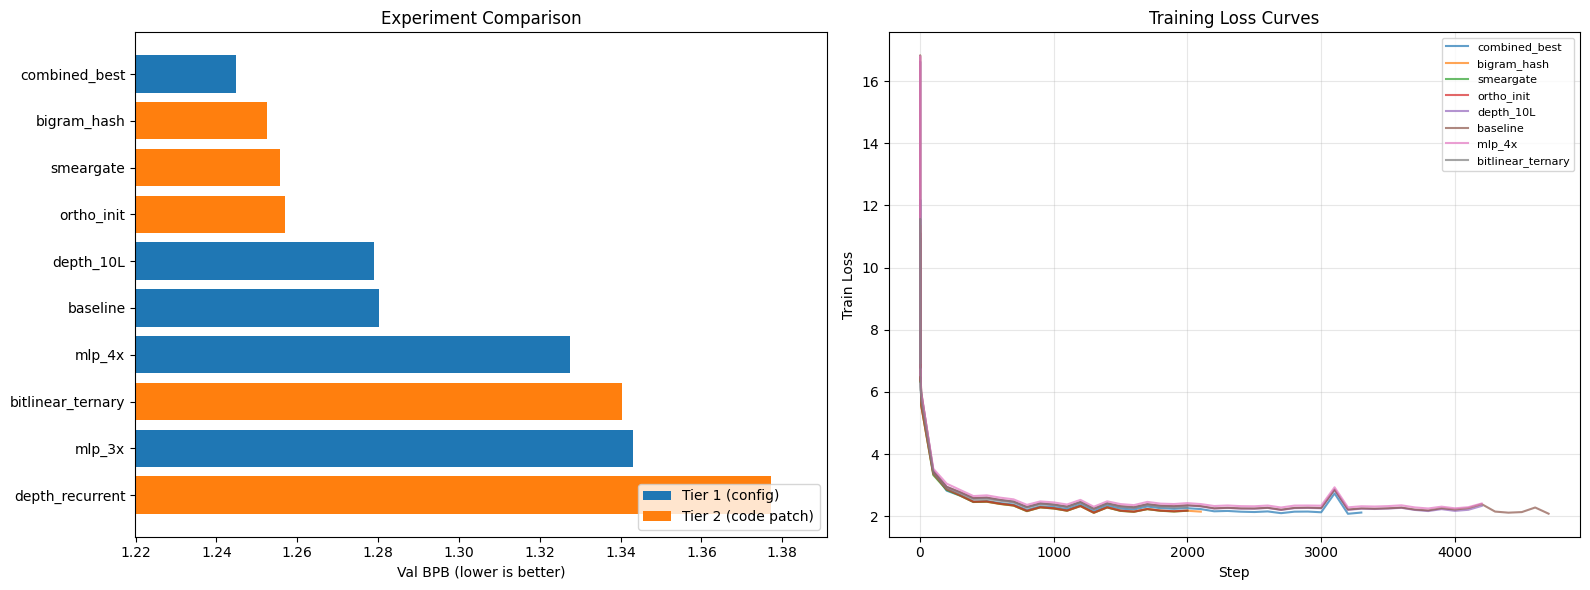


Best: combined_best with BPB=1.2448


In [14]:
import json as jsonlib
import matplotlib.pyplot as plt

# Load results from Google Drive (persisted across sessions) + local experiments
DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments"
LOCAL_DIR = "experiments"

results = {}
for base_dir in [DRIVE_DIR, LOCAL_DIR]:
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        # Local results overwrite Drive (newer)
        results[r["experiment"]] = r

results = list(results.values())

if not results:
    print("No experiment results found.")
    print(f"  Checked: {DRIVE_DIR}")
    print(f"  Checked: {LOCAL_DIR}")
    print("Run some experiments first, then save to Drive!")
else:
    # Sort by BPB (best first)
    results.sort(key=lambda r: r.get("val_bpb", 999))

    # Print summary table
    print(f"{'Experiment':<22} {'BPB':>8} {'Loss':>8} {'Steps':>7} {'Time':>6} {'Size MB':>8} {'Tier':>5}")
    print("-" * 75)
    for r in results:
        print(
            f"{r['experiment']:<22} "
            f"{r.get('val_bpb', 0):>8.4f} "
            f"{r.get('val_loss', 0):>8.4f} "
            f"{r.get('total_steps', 0):>7} "
            f"{r.get('elapsed_seconds', 0):>5.0f}s "
            f"{r.get('artifact_bytes', 0)/1e6:>7.2f} "
            f"{'  T' + str(r.get('tier', '?')):>5}"
        )

    # Plot BPB comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    names = [r["experiment"] for r in results]
    bpbs = [r.get("val_bpb", 0) for r in results]
    colors = ["tab:orange" if r.get("tier") == 2 else "tab:blue" for r in results]

    axes[0].barh(names, bpbs, color=colors)
    axes[0].set_xlabel("Val BPB (lower is better)")
    axes[0].set_title("Experiment Comparison")
    axes[0].invert_yaxis()
    if bpbs:
        axes[0].set_xlim(min(bpbs) * 0.98, max(bpbs) * 1.01)
    axes[0].legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, fc="tab:blue", label="Tier 1 (config)"),
            plt.Rectangle((0, 0), 1, 1, fc="tab:orange", label="Tier 2 (code patch)"),
        ],
        loc="lower right",
    )

    # Plot loss curves overlay (check both Drive and local)
    for exp_name in names[:8]:
        log_path = None
        for base_dir in [LOCAL_DIR, DRIVE_DIR]:
            candidate = f"{base_dir}/{exp_name}/train.log"
            if os.path.exists(candidate):
                log_path = candidate
                break
        if log_path:
            with open(log_path) as f:
                log_text = f.read()
            steps, losses = [], []
            for m in re.finditer(r"step:(\d+).*?train_loss:([\d.]+)", log_text):
                steps.append(int(m.group(1)))
                losses.append(float(m.group(2)))
            if steps:
                axes[1].plot(steps, losses, label=exp_name, alpha=0.7)

    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Train Loss")
    axes[1].set_title("Training Loss Curves")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Best experiment
    best = results[0]
    print(f"\nBest: {best['experiment']} with BPB={best.get('val_bpb', '?')}")

In [15]:
import shutil
from datetime import datetime

# Destination folder on Drive
DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments"

# Copy experiment results
copied = []
if os.path.exists("experiments"):
    for exp_name in sorted(os.listdir("experiments")):
        src = f"experiments/{exp_name}"
        dst = f"{DRIVE_DIR}/{exp_name}"
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            copied.append(exp_name)

# Copy training logs
logs_dst = f"{DRIVE_DIR}/logs"
os.makedirs(logs_dst, exist_ok=True)
if os.path.exists("logs"):
    for log_file in globmod.glob("logs/*.txt"):
        shutil.copy2(log_file, logs_dst)

# Copy model artifacts if they exist
for artifact in ["final_model.pt", "final_model.int8.ptz"]:
    if os.path.exists(artifact):
        shutil.copy2(artifact, DRIVE_DIR)

print(f"Saved to: {DRIVE_DIR}")
print(f"Experiments copied: {', '.join(copied) if copied else '(none found)'}")
print(f"Logs: {len(globmod.glob(f'{logs_dst}/*.txt'))} files")
print(f"\nDrive contents:")
for item in sorted(os.listdir(DRIVE_DIR)):
    full = f"{DRIVE_DIR}/{item}"
    if os.path.isdir(full):
        files = os.listdir(full)
        print(f"  {item}/ ({len(files)} files)")
    else:
        size_mb = os.path.getsize(full) / 1e6
        print(f"  {item} ({size_mb:.1f} MB)")

Saved to: /content/drive/MyDrive/parameter-golf-experiments
Experiments copied: depth_10L
Logs: 14 files

Drive contents:
  baseline/ (2 files)
  bigram_hash/ (2 files)
  bitlinear_ternary/ (2 files)
  combined_best/ (2 files)
  depth_10L/ (2 files)
  depth_recurrent/ (2 files)
  final_model.int8.ptz (17.5 MB)
  final_model.pt (74.6 MB)
  logs/ (14 files)
  mlp_3x/ (2 files)
  mlp_4x/ (2 files)
  ortho_init/ (2 files)
  smeargate/ (2 files)
